In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd
from sklearn.metrics import adjusted_mutual_info_score
import tqdm

## Feature redundancy via boundary-detection AMI

The right measure of redundancy for this study is whether two features detect the same
functional state boundaries, not whether they have similar QSDA quality scores.  Two
features can both score well while identifying entirely different transitions.

For each feature, the QSDA procedure already stored its individual boundary detections in
`edges_lists.txt`.  We convert each detection to an epoch-level stage-label sequence and
compute the Adjusted Mutual Information (AMI) between every pair of features.  High AMI
means the two features find the same boundaries → they are redundant.  Low AMI means they
find different structure → they are complementary.

To keep the computation tractable we sample the top-K features by QSDA score from each
descriptor family and run the analysis for subjects 1–3.

In [3]:
SUBJS     = ['Subj1', 'Subj2', 'Subj3']
EXP       = 'exp_reduced_flow'
TOP_K     = 30   # features sampled per family

FAMILY_MAP = {
    'life':       'Lifetime',
    'bd2':        'Betti curves',
    'landscape':  'Landscape',
    'silhouette': 'Silhouette',
    'amplitude':  'Amplitude',
    'entropy':    'Entropy',
}
FAMILY_ORDER = list(FAMILY_MAP.keys())

def descriptor_family(name: str) -> str:
    token = name.split()[1]
    if token.startswith('amplitude'):
        return 'amplitude'
    if token.startswith('silhouette'):
        return 'silhouette'
    return token

def boundaries_to_labels(edges: np.ndarray, n_epochs: int) -> np.ndarray:
    """Convert sorted boundary array to per-epoch stage index."""
    labels = np.zeros(n_epochs, dtype=np.int32)
    edges = np.clip(edges, 0, n_epochs)
    for k, (a, b) in enumerate(zip(edges[:-1], edges[1:])):
        labels[a:b] = k
    return labels

def load_best_boundaries(feat_dir: Path) -> np.ndarray | None:
    """Load the boundary detection with the most stages from edges_lists.txt."""
    txt = feat_dir / 'edges_lists.txt'
    if not txt.exists():
        return None
    best, best_len = None, 0
    for line in txt.read_text().strip().splitlines():
        nums = np.array([int(x) for x in re.findall(r'\d+', line)])
        if len(nums) > best_len:
            best, best_len = nums, len(nums)
    return best

In [4]:
# For each subject: load QSDA scores, sample top-K per family,
# load their boundary detections, and store epoch-level labels.

subject_data = {}   # subj -> {'labels': (n_features_sampled, n_epochs), 'feature_families': list}

for subj in SUBJS:
    qsda_root  = Path(f'E:/CourseProject/{subj}/{EXP}/qsda')
    scores_csv = qsda_root / 'scores.csv'
    if not scores_csv.exists():
        print(f'{subj}: scores.csv not found, skipping')
        continue

    scores = pd.read_csv(scores_csv)
    scores['family'] = scores['name'].map(descriptor_family)
    scores = scores[scores['family'].isin(FAMILY_ORDER)]

    # Sample top-K per family (by QSDA normalized score)
    sampled = (
        scores.groupby('family', group_keys=False)
              .apply(lambda g: g.nlargest(TOP_K, 'normalized_score'))
    ).reset_index(drop=True)

    # Infer n_epochs from any stored result
    result_csv = Path(f'E:/CourseProject/{subj}/{EXP}/results/best_topological/best_edges.txt')
    best_edges = np.loadtxt(result_csv).astype(int)
    n_epochs   = int(best_edges[-1])

    # Load boundary detections
    label_rows   = []
    feat_families = []
    for _, row in tqdm.tqdm(sampled.iterrows(), total=len(sampled), desc=subj):
        feat_dir = qsda_root / row['name']
        edges    = load_best_boundaries(feat_dir)
        if edges is None or len(edges) < 2:
            continue
        label_rows.append(boundaries_to_labels(edges, n_epochs))
        feat_families.append(row['family'])

    subject_data[subj] = {
        'labels':   np.stack(label_rows),   # (n_sampled, n_epochs)
        'families': feat_families,
    }
    print(f'{subj}: {len(feat_families)} features loaded, {n_epochs} epochs')

C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_24488\3166132713.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(TOP_K, 'normalized_score'))
Subj1: 100%|██████████| 180/180 [00:02<00:00, 74.72it/s] 
C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_24488\3166132713.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(TOP_K, 'normalized_score')

Subj1: 180 features loaded, 1046 epochs


Subj2: 100%|██████████| 180/180 [00:02<00:00, 77.38it/s] 

Subj2: 180 features loaded, 2017 epochs
Subj3: scores.csv not found, skipping


In [5]:
# Compute pairwise AMI matrix per subject, then average.
# All subjects should have the same feature set (same family × rank ordering),
# so we align by position.

def pairwise_ami(labels: np.ndarray) -> np.ndarray:
    """labels: (n_features, n_epochs). Returns (n_features, n_features) AMI matrix."""
    n = len(labels)
    ami = np.eye(n, dtype=np.float32)
    for i in tqdm.trange(n, desc='AMI rows', leave=False):
        for j in range(i + 1, n):
            v = adjusted_mutual_info_score(labels[i], labels[j])
            ami[i, j] = ami[j, i] = v
    return ami

ami_matrices = {}
families_ref = None

for subj, data in subject_data.items():
    print(f'Computing AMI for {subj}...')
    ami_matrices[subj] = pairwise_ami(data['labels'])
    if families_ref is None:
        families_ref = data['families']

# Average across subjects (they should have the same feature order)
ami_mean = np.mean(list(ami_matrices.values()), axis=0)
print(f'Mean AMI matrix shape: {ami_mean.shape}')

Computing AMI for Subj1...


Computing AMI for Subj2...


Mean AMI matrix shape: (180, 180)


In [6]:
# Aggregate: mean AMI within and between descriptor families.
families_arr = np.array(families_ref)
n_fam  = len(FAMILY_ORDER)
inter_ami = np.zeros((n_fam, n_fam))
inter_sem = np.zeros((n_fam, n_fam))

for i, fa in enumerate(FAMILY_ORDER):
    idx_a = np.where(families_arr == fa)[0]
    for j, fb in enumerate(FAMILY_ORDER):
        idx_b = np.where(families_arr == fb)[0]
        block = ami_mean[np.ix_(idx_a, idx_b)]
        if i == j:
            mask = ~np.eye(len(idx_a), dtype=bool)
            vals = block[mask]
        else:
            vals = block.ravel()
        inter_ami[i, j] = vals.mean()
        inter_sem[i, j] = vals.std() / np.sqrt(len(vals))

labels_display = [FAMILY_MAP[f] for f in FAMILY_ORDER]
print('Mean inter-family AMI:')
print(pd.DataFrame(inter_ami, index=labels_display, columns=labels_display).round(3).to_string())

Mean inter-family AMI:
              Lifetime  Betti curves  Landscape  Silhouette  Amplitude  Entropy
Lifetime         0.756         0.749      0.699       0.690      0.700    0.705
Betti curves     0.749         0.772      0.690       0.679      0.687    0.705
Landscape        0.699         0.690      0.722       0.729      0.725    0.663
Silhouette       0.690         0.679      0.729       0.765      0.755    0.645
Amplitude        0.700         0.687      0.725       0.755      0.741    0.656
Entropy          0.705         0.705      0.663       0.645      0.656    0.707


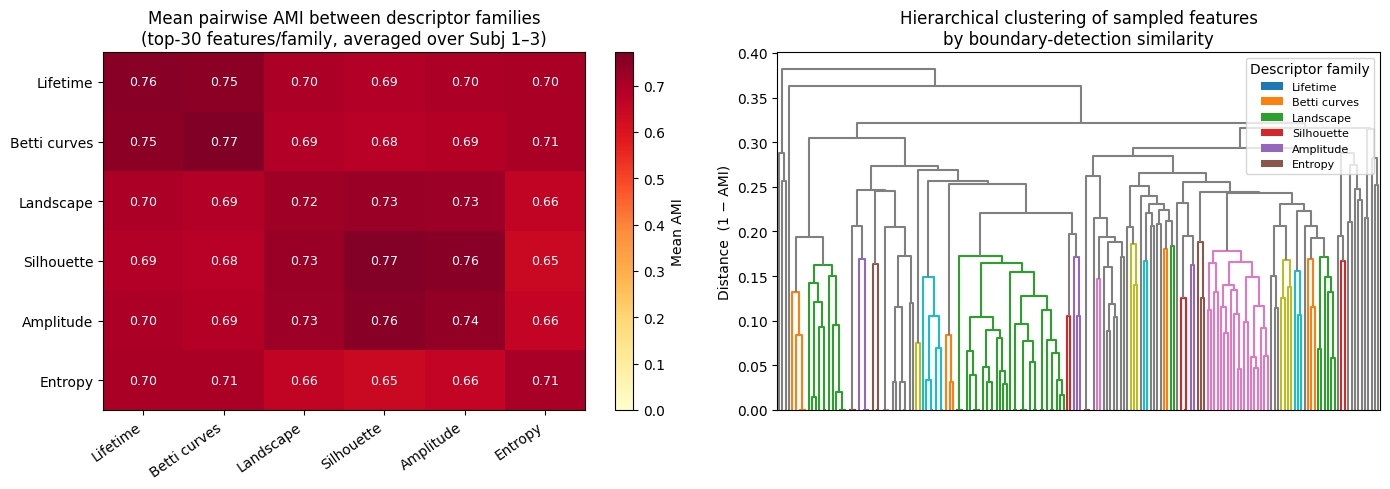

In [7]:
FAMILY_COLORS = {
    'life': 'C0', 'bd2': 'C1', 'landscape': 'C2',
    'silhouette': 'C3', 'amplitude': 'C4', 'entropy': 'C5'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- inter-family AMI heatmap ---
ax = axes[0]
im = ax.imshow(inter_ami, cmap='YlOrRd', vmin=0, vmax=inter_ami.max(), aspect='auto')
ax.set_xticks(range(n_fam))
ax.set_xticklabels(labels_display, rotation=35, ha='right')
ax.set_yticks(range(n_fam))
ax.set_yticklabels(labels_display)
for i in range(n_fam):
    for j in range(n_fam):
        ax.text(j, i, f'{inter_ami[i,j]:.2f}', ha='center', va='center',
                fontsize=9,
                color='white' if inter_ami[i,j] > 0.6 * inter_ami.max() else 'black')
plt.colorbar(im, ax=ax, label='Mean AMI')
ax.set_title('Mean pairwise AMI between descriptor families\n'
             f'(top-{TOP_K} features/family, averaged over Subj 1–3)')

# --- clustered heatmap of all sampled features ---
ax2 = axes[1]
dist = ssd.squareform(np.clip(1 - ami_mean, 0, None))
linkage = sch.linkage(dist, method='average')
dend = sch.dendrogram(
    linkage, ax=ax2, no_labels=True,
    color_threshold=0.5 * linkage[-1, 2],
    above_threshold_color='grey',
)
ax2.set_ylabel('Distance  (1 − AMI)')
ax2.set_title('Hierarchical clustering of sampled features\nby boundary-detection similarity')

# colour-coded legend for families
patches = [mpatches.Patch(facecolor=FAMILY_COLORS[f], label=FAMILY_MAP[f])
           for f in FAMILY_ORDER]
ax2.legend(handles=patches, loc='upper right', fontsize=8, title='Descriptor family')

fig.tight_layout()
fig.savefig('feature_redundancy.svg')
plt.show()

In [8]:
# Summary: within- vs between-family AMI
within  = [inter_ami[i, i] for i in range(n_fam)]
off_diag = [inter_ami[i, j] for i in range(n_fam) for j in range(n_fam) if i != j]

print(f'Within-family AMI:   mean={np.mean(within):.3f},  range [{min(within):.3f}, {max(within):.3f}]')
print(f'Between-family AMI:  mean={np.mean(off_diag):.3f}, range [{min(off_diag):.3f}, {max(off_diag):.3f}]')
print()
print('Per-family within-AMI (higher = more internally redundant):')
for f, w in sorted(zip(FAMILY_ORDER, within), key=lambda x: -x[1]):
    print(f'  {FAMILY_MAP[f]:<14}: {w:.3f}')

Within-family AMI:   mean=0.744,  range [0.707, 0.772]
Between-family AMI:  mean=0.699, range [0.645, 0.755]

Per-family within-AMI (higher = more internally redundant):
  Betti curves  : 0.772
  Silhouette    : 0.765
  Lifetime      : 0.756
  Amplitude     : 0.741
  Landscape     : 0.722
  Entropy       : 0.707
